# Let's take a peek at the data

In [1]:
!git clone https://github.com/batuhan-gundogdu/machine-learning-II.git
%cd machine-learning-II/Lecture\ 1

fatal: destination path 'machine-learning-II' already exists and is not an empty directory.
/content/machine-learning-II/Lecture 1


torch.Size([16, 1, 32, 32])
torch.Size([16])


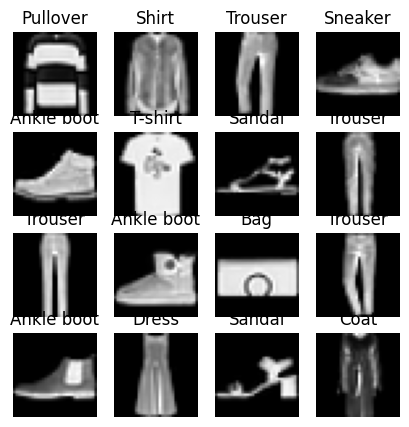

In [2]:
# Let's take a peek at the data
from data_loader import Data

data = Data()
data.peek()


# Let's create our first model and see how it works

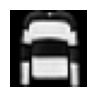

Model output: Trouser


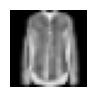

Model output: Sneaker


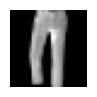

Model output: Sneaker


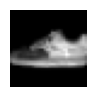

Model output: Shirt


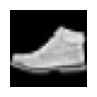

Model output: Ankle boot


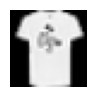

Model output: Coat


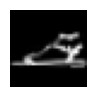

Model output: Ankle boot


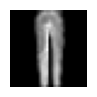

Model output: Sneaker


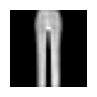

Model output: Pullover


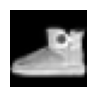

Model output: Ankle boot


In [3]:
from model import Model
from data_loader import Data
import random
import matplotlib.pyplot as plt
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(16)

model = Model().to(device) # Just a baby now, it doesn't know anything
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(10):
    # get the ith sample of the first batch
    sample_data = data.dataloader.dataset[i][0].to(device)
    plt.figure(figsize=(1, 1))
    plt.imshow(sample_data.squeeze().to("cpu").numpy(), cmap='gray')
    plt.axis('off')
    plt.show()
    output = model.predict(sample_data)
    print(f'Model output: {class_names[output]}')



# Let's train our very first AI model, it's a black box now and when you tie it to the data and it's labels and ask it to train, it magically does so. Don't worry, we will open up this box very soon.

In [4]:
model.train(data.dataloader)

Training the model: 100%|██████████| 20/20 [00:00<00:00, 39.16it/s]


# Let's see how it is doing now, after learning a thing or two from the data

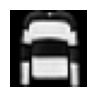

Model output: Pullover


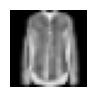

Model output: Shirt


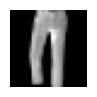

Model output: Trouser


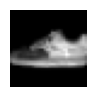

Model output: Sneaker


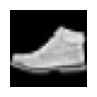

Model output: Ankle boot


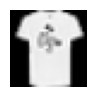

Model output: T-shirt


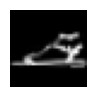

Model output: Sandal


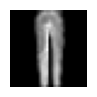

Model output: Trouser


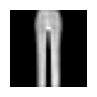

Model output: Trouser


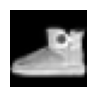

Model output: Ankle boot


In [6]:
for i in range(10):
    # get the ith sample of the first batch
    sample_data = data.dataloader.dataset[i][0]
    plt.figure(figsize=(1, 1))
    plt.imshow(sample_data.squeeze().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.show()
    predicted = model.predict(sample_data)
    print(f'Model output: {class_names[predicted]}')

# It IS learning! Let's see what the average accuracy is

In [7]:

model.test(data.dataloader)

On 800 images, the model achieved an accuracy of 94.125%


# Yay! Should we call it a victory then? We have built a model with an amazing accuracy?

### No :(

In [8]:
unseen_data = Data(test=True)

model.test(unseen_data.dataloader)


On 10000 images, the model achieved an accuracy of 77.82%


## Key Question: So, I learned that I am victorious, if my model performs NOT on the data I have, but *on the data that <I don't have>*. How am I going to guage how well my model will perform on unseen data?

In [9]:
from torch.utils.data import DataLoader, random_split

data = Data()
random.seed(16)

dataset = data.dataloader.dataset  # Get the dataset from the dataloader
val_split = 0.2
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=data.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=data.batch_size, shuffle=False)




In [11]:
model = Model().to(device)
model.train(train_loader, val_dataloader=val_loader, epochs=20)

Epoch 0 - Training Accuracy: 60.0% - Validation Accuracy: 73.75%
Epoch 1 - Training Accuracy: 75.625% - Validation Accuracy: 75.0%
Epoch 2 - Training Accuracy: 80.0% - Validation Accuracy: 77.5%
Epoch 3 - Training Accuracy: 82.5% - Validation Accuracy: 78.125%
Epoch 4 - Training Accuracy: 84.53125% - Validation Accuracy: 79.375%
Epoch 5 - Training Accuracy: 86.5625% - Validation Accuracy: 80.0%
Epoch 6 - Training Accuracy: 86.875% - Validation Accuracy: 78.125%
Epoch 7 - Training Accuracy: 88.59375% - Validation Accuracy: 81.875%
Epoch 8 - Training Accuracy: 89.0625% - Validation Accuracy: 81.25%
Epoch 9 - Training Accuracy: 90.625% - Validation Accuracy: 80.625%
Epoch 10 - Training Accuracy: 91.09375% - Validation Accuracy: 80.625%
Epoch 11 - Training Accuracy: 90.9375% - Validation Accuracy: 81.875%
Epoch 12 - Training Accuracy: 92.03125% - Validation Accuracy: 80.625%
Epoch 13 - Training Accuracy: 91.40625% - Validation Accuracy: 76.25%
Epoch 14 - Training Accuracy: 92.65625% - Vali

# Well, I hid something from you. We were looking at only a small portion of the available dataset, now let's use the whole thing and see what happens

In [12]:
data = Data(size=60000)
random.seed(16)
dataset = data.dataloader.dataset  # Get the dataset from the dataloader
val_split = 0.2
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=data.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=data.batch_size, shuffle=False)
model = Model().to(device)
model.train(train_loader, val_dataloader=val_loader, epochs=20)

Epoch 0 - Training Accuracy: 81.16666666666667% - Validation Accuracy: 83.05833333333334%
Epoch 1 - Training Accuracy: 83.575% - Validation Accuracy: 83.74166666666666%
Epoch 2 - Training Accuracy: 83.91041666666666% - Validation Accuracy: 83.68333333333334%
Epoch 3 - Training Accuracy: 84.09375% - Validation Accuracy: 83.475%
Epoch 4 - Training Accuracy: 84.45208333333333% - Validation Accuracy: 84.875%
Epoch 5 - Training Accuracy: 84.37708333333333% - Validation Accuracy: 84.80833333333334%
Epoch 6 - Training Accuracy: 84.57291666666667% - Validation Accuracy: 83.86666666666666%
Epoch 7 - Training Accuracy: 84.45833333333333% - Validation Accuracy: 83.60833333333333%
Epoch 8 - Training Accuracy: 84.91666666666667% - Validation Accuracy: 82.875%
Epoch 9 - Training Accuracy: 84.77708333333334% - Validation Accuracy: 82.28333333333333%
Epoch 10 - Training Accuracy: 84.69375% - Validation Accuracy: 83.85833333333333%
Epoch 11 - Training Accuracy: 84.74583333333334% - Validation Accuracy:

# Uh oh, our model coudn't even learn the training set. There's a name for this "lack of performance from 100%". Let's increase the capacity of the model and see if it helps

In [13]:
data = Data(size=60000)
MODEL_CAPACITY = 2
random.seed(16)
dataset = data.dataloader.dataset  # Get the dataset from the dataloader
val_split = 0.2
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=data.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=data.batch_size, shuffle=False)
model = Model(capacity=MODEL_CAPACITY).to(device)
model.train(train_loader, val_dataloader=val_loader, epochs=20)

Epoch 0 - Training Accuracy: 81.375% - Validation Accuracy: 84.6%
Epoch 1 - Training Accuracy: 85.75% - Validation Accuracy: 86.55%
Epoch 2 - Training Accuracy: 87.33541666666666% - Validation Accuracy: 86.66666666666667%
Epoch 3 - Training Accuracy: 87.94166666666666% - Validation Accuracy: 87.26666666666667%
Epoch 4 - Training Accuracy: 88.57291666666667% - Validation Accuracy: 86.925%
Epoch 5 - Training Accuracy: 88.85833333333333% - Validation Accuracy: 88.23333333333333%
Epoch 6 - Training Accuracy: 89.31041666666667% - Validation Accuracy: 88.08333333333333%
Epoch 7 - Training Accuracy: 89.60625% - Validation Accuracy: 88.66666666666667%
Epoch 8 - Training Accuracy: 89.90416666666667% - Validation Accuracy: 88.29166666666667%
Epoch 9 - Training Accuracy: 90.21875% - Validation Accuracy: 88.24166666666666%
Epoch 10 - Training Accuracy: 90.18541666666667% - Validation Accuracy: 88.2%
Epoch 11 - Training Accuracy: 90.72916666666667% - Validation Accuracy: 88.85%
Epoch 12 - Training 

# Now, the model was able to do better with the training data, but there's still room for improvement in the validation data. After all, it is the validation set performance what the customer will face everyday, right?

### The increase in the capacity seemed to help with our first problem, let's increase it even higher and see if it will help

In [14]:
data = Data(size=60000)
random.seed(16)
dataset = data.dataloader.dataset  # Get the dataset from the dataloader
val_split = 0.2
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=data.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=data.batch_size, shuffle=False)
model = Model(capacity=5).to(device)
model.train(train_loader, val_dataloader=val_loader, epochs=20)

Epoch 0 - Training Accuracy: 77.5% - Validation Accuracy: 83.0%
Epoch 1 - Training Accuracy: 84.68333333333334% - Validation Accuracy: 85.78333333333333%
Epoch 2 - Training Accuracy: 86.32708333333333% - Validation Accuracy: 87.18333333333334%
Epoch 3 - Training Accuracy: 87.08541666666666% - Validation Accuracy: 85.36666666666666%
Epoch 4 - Training Accuracy: 87.60208333333334% - Validation Accuracy: 86.81666666666666%
Epoch 5 - Training Accuracy: 88.29583333333333% - Validation Accuracy: 87.125%
Epoch 6 - Training Accuracy: 88.67291666666667% - Validation Accuracy: 88.23333333333333%
Epoch 7 - Training Accuracy: 88.82291666666667% - Validation Accuracy: 87.19166666666666%
Epoch 8 - Training Accuracy: 89.26666666666667% - Validation Accuracy: 86.91666666666667%
Epoch 9 - Training Accuracy: 89.48541666666667% - Validation Accuracy: 88.25833333333334%
Epoch 10 - Training Accuracy: 89.81041666666667% - Validation Accuracy: 87.5%
Epoch 11 - Training Accuracy: 89.77708333333334% - Validati

# I really hope that the validation set in fact represents my client's data, and the training set I used was good. What if I was just lucky with my validation set? What if I check with variaous validation sets and see if the performances vary

In [18]:
MODEL_CAPACITY = 0
data = Data(size=20000)
random.seed(16)
dataset = data.dataloader.dataset  # Get the dataset from the dataloader
val_split = 0.2
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# get 5 random bootstrap samples from the training set
bootstrap_samples = random_split(train_dataset, [0.2, 0.2, 0.2, 0.2, 0.2])

for bootstrap_sample in bootstrap_samples:
    train_loader = DataLoader(bootstrap_sample, batch_size=data.batch_size, shuffle=True)
    model = Model(capacity=MODEL_CAPACITY).to(device)
    model.train(train_loader, epochs=20)
    model.test(val_loader)


Training the model: 100%|██████████| 20/20 [00:01<00:00, 17.23it/s]


On 12000 images, the model achieved an accuracy of 82.55833333333334%


Training the model: 100%|██████████| 20/20 [00:01<00:00, 17.27it/s]


On 12000 images, the model achieved an accuracy of 82.475%


Training the model: 100%|██████████| 20/20 [00:01<00:00, 17.29it/s]


On 12000 images, the model achieved an accuracy of 82.775%


Training the model: 100%|██████████| 20/20 [00:01<00:00, 17.31it/s]


On 12000 images, the model achieved an accuracy of 82.625%


Training the model: 100%|██████████| 20/20 [00:01<00:00, 17.38it/s]

On 12000 images, the model achieved an accuracy of 81.75833333333334%


In [19]:
MODEL_CAPACITY = 5
data = Data(size=20000)
random.seed(16)
dataset = data.dataloader.dataset  # Get the dataset from the dataloader
val_split = 0.2
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# get 5 random bootstrap samples from the training set
bootstrap_samples = random_split(train_dataset, [0.2, 0.2, 0.2, 0.2, 0.2])

for bootstrap_sample in bootstrap_samples:
    train_loader = DataLoader(bootstrap_sample, batch_size=data.batch_size, shuffle=True)
    model = Model(capacity=MODEL_CAPACITY).to(device)
    model.train(train_loader, epochs=20)
    model.test(val_loader)

Training the model: 100%|██████████| 20/20 [00:02<00:00,  7.55it/s]


On 12000 images, the model achieved an accuracy of 82.93333333333334%


Training the model: 100%|██████████| 20/20 [00:02<00:00,  7.57it/s]


On 12000 images, the model achieved an accuracy of 83.625%


Training the model: 100%|██████████| 20/20 [00:02<00:00,  7.53it/s]


On 12000 images, the model achieved an accuracy of 80.65%


Training the model: 100%|██████████| 20/20 [00:02<00:00,  7.56it/s]


On 12000 images, the model achieved an accuracy of 82.05833333333334%


Training the model: 100%|██████████| 20/20 [00:02<00:00,  7.53it/s]


On 12000 images, the model achieved an accuracy of 84.68333333333334%


(back to slides)